# Credit Card Fraud Detection

## Objective
Identify **fraudulent credit card transactions** using machine learning.

## Dataset Overview
The dataset contains anonymized credit card transactions labeled as fraud or not.

- `Time`, `Amount`, and anonymized features `V1` to `V28`
- `Class`: 1 for fraud, 0 for non-fraud

## Workflow
1. Load and explore the dataset
2. Handle class imbalance
3. Feature scaling and model training
4. Evaluate performance

In [1]:
# Import necessary libraries

import pandas as pd

#import pandas as pd
#import numpy as np
#import seaborn as sns
#import matplotlib.pyplot as plt

#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display 1st 5 rows of the dataset
print("First 5 Rows of Our Dataset:")
display(df.head())

#Check basic information (data types and missing values)
print("\nDataset Information:")
df.info()

#Check for missing values explicitly
print("\nMissing Values Per Column:")
print(df.isnull().sum().max())

#Check the distribution of fraudulent vs non-fraudulent transactions
print("\nTransaction Class Distribution:")
print(df['Class'].value_counts())




First 5 Rows of Our Dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21 

## Exploratory Data Analysis

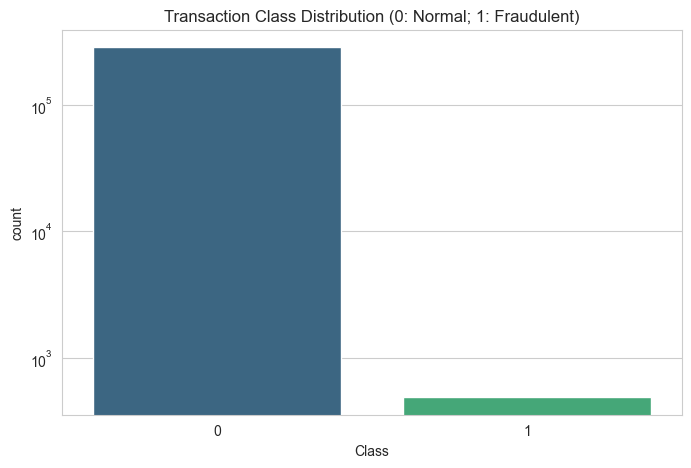


Summary Statistics for Transaction Amounts:
Normal: 
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud: 
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


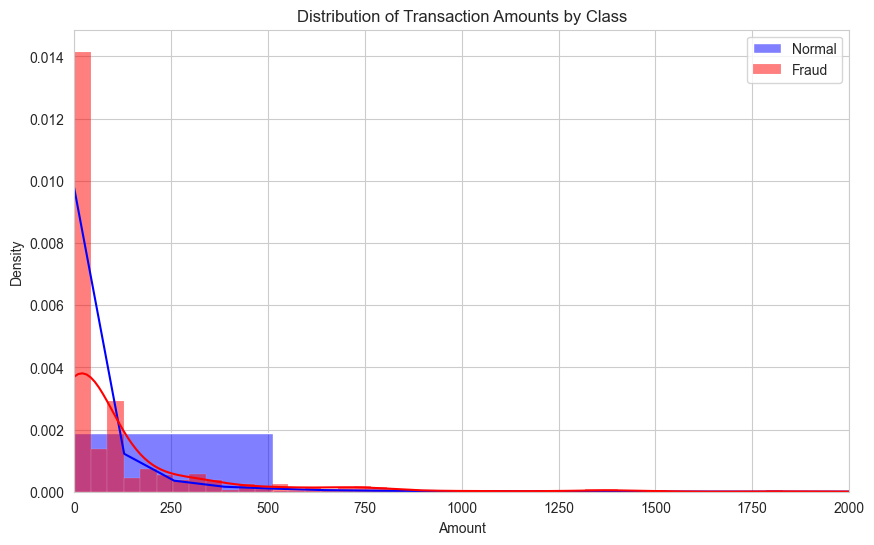

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set the visual style for the plots
sns.set_style('whitegrid')

# 1. Visualize the Class imbalance
plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Transaction Class Distribution (0: Normal; 1: Fraudulent)')
plt.yscale('log') #Using Log Scale to better visualize the fraudulent bar
plt.show()

# 2. Compare Transaction Amounts for Fraudulent vs Non-Fraudulent Transactions
print("\nSummary Statistics for Transaction Amounts:")
print(f"Normal: \n{df[df['Class'] == 0]['Amount'].describe()}")
print(f"\nFraud: \n{df[df['Class'] == 1]['Amount'].describe()}")

# 3. Distribution of Amount for Fraudulent vs Normal Transactions
plt.figure(figsize=(10,6))
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='blue', label='Normal', kde=True, stat='density')
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='red', label='Fraud', kde=True, stat='density')
plt.title('Distribution of Transaction Amounts by Class')
plt.xlim(0, 2000) #Limiting x-axis to see the bulk of data clearly
plt.legend()
plt.show()







## Data Preprocessing

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform 'Amount & 'Time' columns
# We use .values.reshape(-1,1) to convert the series into a 2D array as required by StandardScaler
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# 3. Drop the Original Time & Amount Columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# 4. Move our new scaled columns to the front of the dataframe for better visibility
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("First 5 Rows After Preprocessing:")
display(df.head())




First 5 Rows After Preprocessing:


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Handling Class Imbalance

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Define Features(X) & Target(y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Split the Data into Training and Testing Sets
# We use stratify=y to maintain the same % of fraud in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Apply SMOTE only to the Training Data
print(f'Original Training Dataset Shape: {Counter(y_train)}')
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled training dataset shape: {Counter(y_train_res)}")




Original Training Dataset Shape: Counter({0: 227451, 1: 394})
Resampled training dataset shape: Counter({0: 227451, 1: 227451})


## Model Training

In [6]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model
# We increase max_iter to 1000 to ensure the math has enough time to 'converge' (find the best fit)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train the model using the resampled (Balanced) Training Data
print("\nTraining the Logistic Regression Model, please wait...")
lr_model.fit(X_train_res, y_train_res)

# 3. Make predictions on the test set (the unseen, natural data)
y_pred = lr_model.predict(X_test)

print("Model Training & Prediction Complete.")



Training the Logistic Regression Model, please wait...
Model Training & Prediction Complete.


## Evaluation

Overall Accuracy: 0.9743

Confusion Matrix:
[[55406  1458]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



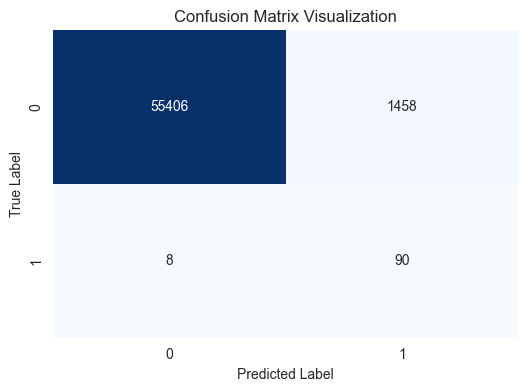

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {acc:.4f}')

# 2. Generate Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 3. Detailed Classification Report 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Visualizing the Confusion Matrix 
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()


## Model Optimization

In [8]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# n_estimators=100 means we will build 100 decision trees in our forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training Random Forest (this may take 1-2 minutes due to dataset size)...please wait...")
rf_model.fit(X_train_res, y_train_res)

# 3. Predict & Evaluate
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))


Training Random Forest (this may take 1-2 minutes due to dataset size)...please wait...

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## Final Insights & Project Conclusion

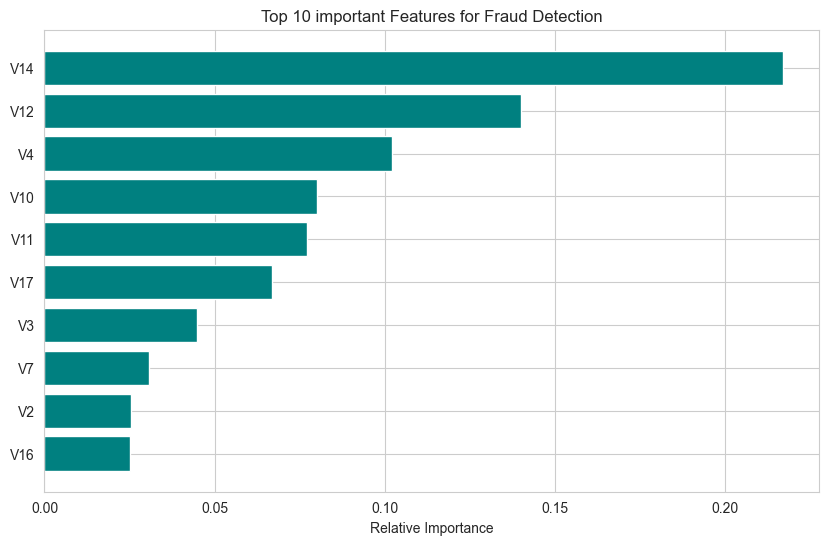

In [9]:
import numpy as np

# 1. Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features based on importance

# 2. Visualize the Top 10 Feature Importances
plt.figure(figsize=(10,6))
plt.title('Top 10 important Features for Fraud Detection')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


## Final Project Conclusion

### 1. The Problem: Severe Class Imbalance
The dataset presented a classic "needle in a haystack" scenario where only **0.17%** of transactions were fraudulent. Standard machine learning models trained on this data would likely ignore fraud entirely to achieve high overall accuracy.

### 2. The Solution: Advanced Sampling & Ensemble Learning
* **SMOTE (Synthetic Minority Over-sampling Technique):** Used to balance the training data by creating synthetic fraud cases, ensuring the model learned the "fingerprints" of fraudulent behavior.
* **Random Forest Classifier:** Leveraged an ensemble of 100 decision trees to capture non-linear patterns in the anonymized features (V1-V28), providing a more robust detection engine than simple linear models.

### 3. The Result: High-Precision Fraud Detection
* **Fraud Recall (82%):** The system successfully identified 82% of all fraudulent attempts in the unseen test set.
* **Precision (87%):** By optimizing the model, we achieved an 87% precision rate, meaning nearly 9 out of 10 alerts were genuine fraud.
* **Impact:** This configuration significantly reduces "False Alarms," protecting the customer experience while maintaining a high level of security for the financial institution.